In [1]:
!pip -q install transformers accelerate

import glob, shutil, os

files = glob.glob('/kaggle/input/**/*.jsonl', recursive=True)
print(f"found {len(files)} jsonl files")
for f in files:
    shutil.copy(f, '/kaggle/working/')

os.chdir('/kaggle/working')
!ls -la *.jsonl


found 9 jsonl files
-rw-r--r-- 1 root root  333373 Sep 20 13:26 gold_test_annotated.jsonl
-rw-r--r-- 1 root root  172620 Sep 20 13:26 gold_val_annotated.jsonl
-rw-r--r-- 1 root root  723089 Sep 20 13:26 scierc_claude.jsonl
-rw-r--r-- 1 root root   74202 Sep 20 13:26 scierc_dev.jsonl
-rw-r--r-- 1 root root  733351 Sep 20 13:26 scierc_gold.jsonl
-rw-r--r-- 1 root root  150082 Sep 20 13:26 scierc_test.jsonl
-rw-r--r-- 1 root root  509067 Sep 20 13:26 scierc_train.jsonl
-rw-r--r-- 1 root root 4267746 Sep 20 13:26 train_annotated.jsonl
-rw-r--r-- 1 root root 2559925 Sep 20 13:26 train_pool_subset.jsonl


In [2]:
%%writefile train_ner.py
"""
Phase D — fine-tune SciBERT on Claude-annotated spans, evaluate entity-level.

Kaggle (GPU T4 x2, internet on):
    !pip -q install transformers datasets accelerate
    !python train_ner.py --train train_annotated.jsonl \
                         --val   gold_val_annotated.jsonl \
                         --test  gold_test_annotated.jsonl \
                         --seeds 1

Local smoke test (CPU, tiny):
    python train_ner.py --train ... --val ... --limit 200 --epochs 1

Design notes:

1. NO CHUNKING. max_length=512 covers title+abstract for essentially every
   record; the truncation rate is printed so you can verify. Chunking is a
   whole class of offset bugs you do not need for a PoC.

2. CHAR OFFSETS -> BIO via the fast tokenizer's offset_mapping, and back
   again for prediction. The canonical `text` string is the only thing both
   sides agree on, so everything is anchored to it.

3. EVAL IS ENTITY-LEVEL, not token-level. Strict (exact span + label) and
   partial (any overlap + label) are both reported: if strict is far below
   partial, your problem is boundaries, not recognition.

4. BASELINE. A gazetteer built from training surface forms. This is the floor
   the model must clear to justify itself.
"""

from __future__ import annotations

import argparse
import json
import random
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)

MODEL_NAME = "allenai/scibert_scivocab_uncased"
MAX_LENGTH = 512
ENTITY_TYPES = ["METHOD", "TASK"]

LABELS = ["O"] + [f"{p}-{t}" for t in ENTITY_TYPES for p in ("B", "I")]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}


# --------------------------------------------------------------------------
# Data
# --------------------------------------------------------------------------

def load(path: Path, limit: int | None = None) -> list[dict]:
    records = []
    with path.open(encoding="utf-8") as fh:
        for line in fh:
            if not line.strip():
                continue
            record = json.loads(line)
            if record.get("error") or not record.get("text"):
                continue
            records.append(record)
    if limit:
        records = records[:limit]
    return records


class SpanDataset(Dataset):
    def __init__(self, records, tokenizer):
        self.features = []
        truncated = 0

        for record in records:
            enc = tokenizer(
                record["text"],
                truncation=True,
                max_length=MAX_LENGTH,
                return_offsets_mapping=True,
            )
            offsets = enc["offset_mapping"]
            if offsets and offsets[-2][1] < len(record["text"]) - 1:
                truncated += 1

            labels = [LABEL2ID["O"]] * len(offsets)
            for i, (start, end) in enumerate(offsets):
                if start == end:                      # special token
                    labels[i] = -100

            for entity in record.get("entities", []):
                e_start, e_end, etype = entity["start"], entity["end"], entity["label"]
                if etype not in ENTITY_TYPES:
                    continue
                first = True
                for i, (start, end) in enumerate(offsets):
                    if start == end or end <= e_start or start >= e_end:
                        continue
                    labels[i] = LABEL2ID[("B-" if first else "I-") + etype]
                    first = False

            self.features.append({
                "input_ids": enc["input_ids"],
                "attention_mask": enc["attention_mask"],
                "labels": labels,
                "offsets": offsets,
                "text": record["text"],
                "gold": [(e["start"], e["end"], e["label"])
                         for e in record.get("entities", [])
                         if e["label"] in ENTITY_TYPES],
            })

        if truncated:
            print(f"  warning: {truncated}/{len(records)} records truncated "
                  f"at {MAX_LENGTH} tokens")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, i):
        f = self.features[i]
        return {k: f[k] for k in ("input_ids", "attention_mask", "labels")}


def collate(batch, pad_id):
    width = max(len(b["input_ids"]) for b in batch)
    out = defaultdict(list)
    for b in batch:
        pad = width - len(b["input_ids"])
        out["input_ids"].append(b["input_ids"] + [pad_id] * pad)
        out["attention_mask"].append(b["attention_mask"] + [0] * pad)
        out["labels"].append(b["labels"] + [-100] * pad)
    return {k: torch.tensor(v) for k, v in out.items()}


# --------------------------------------------------------------------------
# BIO -> character spans
# --------------------------------------------------------------------------

def decode_spans(pred_ids, offsets) -> list[tuple[int, int, str]]:
    spans, current = [], None
    for label_id, (start, end) in zip(pred_ids, offsets):
        if start == end:
            continue
        label = ID2LABEL.get(int(label_id), "O")
        if label == "O":
            if current:
                spans.append(current)
                current = None
            continue
        prefix, etype = label.split("-", 1)
        if prefix == "B" or current is None or current[2] != etype:
            if current:
                spans.append(current)
            current = (start, end, etype)
        else:
            current = (current[0], end, etype)
    if current:
        spans.append(current)
    return spans


# --------------------------------------------------------------------------
# Entity-level scoring
# --------------------------------------------------------------------------

def prf(tp: int, n_pred: int, n_gold: int) -> tuple[float, float, float]:
    p = tp / n_pred if n_pred else 0.0
    r = tp / n_gold if n_gold else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f


def score(all_gold, all_pred, etype: str | None = None) -> dict:
    def keep(spans):
        return [s for s in spans if etype is None or s[2] == etype]

    strict_tp = partial_tp = n_pred = n_gold = 0

    for gold, pred in zip(all_gold, all_pred):
        gold, pred = keep(gold), keep(pred)
        n_pred += len(pred)
        n_gold += len(gold)

        gold_set = set(gold)
        strict_tp += len(gold_set & set(pred))

        unmatched = list(gold)
        for p_start, p_end, p_type in pred:
            for i, (g_start, g_end, g_type) in enumerate(unmatched):
                if g_type == p_type and p_start < g_end and p_end > g_start:
                    partial_tp += 1
                    unmatched.pop(i)
                    break

    sp, sr, sf = prf(strict_tp, n_pred, n_gold)
    pp, pr_, pf = prf(partial_tp, n_pred, n_gold)
    return {"strict_p": sp, "strict_r": sr, "strict_f1": sf,
            "partial_p": pp, "partial_r": pr_, "partial_f1": pf,
            "n_gold": n_gold, "n_pred": n_pred}


def show(name: str, results: dict) -> None:
    print(f"\n{name}")
    print(f"  {'type':<8} {'strict P':>9} {'strict R':>9} {'strict F1':>10} "
          f"{'partial F1':>11} {'gold':>6}")
    for key, res in results.items():
        print(f"  {key:<8} {res['strict_p']:>9.3f} {res['strict_r']:>9.3f} "
              f"{res['strict_f1']:>10.3f} {res['partial_f1']:>11.3f} "
              f"{res['n_gold']:>6}")


def evaluate_all(gold_lists, pred_lists) -> dict:
    return {
        "ALL": score(gold_lists, pred_lists),
        **{t: score(gold_lists, pred_lists, t) for t in ENTITY_TYPES},
    }


# --------------------------------------------------------------------------
# Gazetteer baseline
# --------------------------------------------------------------------------

def build_gazetteer(records, min_count: int = 2) -> dict[str, str]:
    counts = defaultdict(lambda: defaultdict(int))
    for record in records:
        for entity in record.get("entities", []):
            surface = record["text"][entity["start"]:entity["end"]].lower()
            if len(surface) > 2:
                counts[surface][entity["label"]] += 1

    gazetteer = {}
    for surface, by_label in counts.items():
        label, n = max(by_label.items(), key=lambda kv: kv[1])
        if n >= min_count:
            gazetteer[surface] = label
    return gazetteer


def gazetteer_predict(text: str, gazetteer: dict[str, str]):
    spans, claimed = [], []
    for surface in sorted(gazetteer, key=len, reverse=True):
        pattern = rf"(?<!\w){re.escape(surface)}s?(?!\w)"
        for match in re.finditer(pattern, text, re.IGNORECASE):
            if any(match.start() < e and match.end() > s for s, e in claimed):
                continue
            spans.append((match.start(), match.end(), gazetteer[surface]))
            claimed.append((match.start(), match.end()))
    return sorted(spans)


# --------------------------------------------------------------------------
# Train / predict
# --------------------------------------------------------------------------

def predict(model, dataset, tokenizer, device, batch_size=16):
    model.eval()
    preds = []
    for i in range(0, len(dataset), batch_size):
        chunk = dataset.features[i:i + batch_size]
        batch = collate(
            [{k: f[k] for k in ("input_ids", "attention_mask", "labels")}
             for f in chunk],
            tokenizer.pad_token_id,
        )
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"]).logits
        argmax = logits.argmax(-1).cpu().numpy()
        for row, feature in zip(argmax, chunk):
            preds.append(decode_spans(row[:len(feature["offsets"])],
                                      feature["offsets"]))
    return preds


def run_seed(seed, train_ds, val_ds, test_ds, tokenizer, args):
    set_seed(seed)
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID,
    )
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    training_args = TrainingArguments(
        output_dir=f"./run_seed{seed}",
        per_device_train_batch_size=args.batch_size,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        warmup_ratio=0.1,
        weight_decay=0.01,
        fp16=torch.cuda.is_available(),
        logging_steps=100,
        save_strategy="no",          # we score manually; no 440MB checkpoints
        report_to=[],
        seed=seed,
    )

    Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        data_collator=lambda b: collate(b, tokenizer.pad_token_id),
    ).train()

    results = {}
    for name, dataset in (("val", val_ds), ("test", test_ds)):
        if dataset is None:
            continue
        preds = predict(model, dataset, tokenizer, device)
        gold = [f["gold"] for f in dataset.features]
        results[name] = evaluate_all(gold, preds)
        show(f"[seed {seed}] {name}", results[name])

    del model
    torch.cuda.empty_cache()
    return results


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--train", type=Path, required=True)
    parser.add_argument("--val", type=Path, required=True)
    parser.add_argument("--test", type=Path)
    parser.add_argument("--seeds", type=int, default=3)
    parser.add_argument("--epochs", type=float, default=3)
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--lr", type=float, default=3e-5)
    parser.add_argument("--limit", type=int)
    args = parser.parse_args()

    random.seed(0)
    np.random.seed(0)

    print("Loading data")
    train_records = load(args.train, args.limit)
    val_records = load(args.val)
    test_records = load(args.test) if args.test else []
    print(f"  train {len(train_records)}  val {len(val_records)}  "
          f"test {len(test_records)}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print("Encoding train"); train_ds = SpanDataset(train_records, tokenizer)
    print("Encoding val");   val_ds = SpanDataset(val_records, tokenizer)
    test_ds = SpanDataset(test_records, tokenizer) if test_records else None

    # ---- baseline -------------------------------------------------------
    gazetteer = build_gazetteer(train_records)
    print(f"\nGazetteer: {len(gazetteer)} surface forms")
    for name, dataset in (("val", val_ds), ("test", test_ds)):
        if dataset is None:
            continue
        preds = [gazetteer_predict(f["text"], gazetteer) for f in dataset.features]
        gold = [f["gold"] for f in dataset.features]
        show(f"[gazetteer] {name}", evaluate_all(gold, preds))

    # ---- model ----------------------------------------------------------
    all_runs = [run_seed(42 + i, train_ds, val_ds, test_ds, tokenizer, args)
                for i in range(args.seeds)]

    print(f"\n{'=' * 60}\nAcross {args.seeds} seed(s): mean +/- std")
    for split in ("val", "test"):
        if split not in all_runs[0]:
            continue
        print(f"\n{split}")
        for key in ["ALL"] + ENTITY_TYPES:
            f1s = [r[split][key]["strict_f1"] for r in all_runs]
            partials = [r[split][key]["partial_f1"] for r in all_runs]
            print(f"  {key:<8} strict {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}"
                  f"   partial {np.mean(partials):.3f} +/- {np.std(partials):.3f}")

    Path("results.json").write_text(json.dumps(all_runs, indent=2))
    print("\nWrote results.json")


if __name__ == "__main__":
    main()


Writing train_ner.py


In [3]:
import shutil

for n in [500, 1000, 1500]:
    print(f"\n{'='*70}\nTRAIN SIZE {n}\n{'='*70}")
    !python train_ner.py --train train_annotated.jsonl \
                         --val   gold_val_annotated.jsonl \
                         --test  gold_test_annotated.jsonl \
                         --limit {n} --seeds 3 --epochs 3
    shutil.move('results.json', f'results_{n}.json')



TRAIN SIZE 500
Loading data
  train 500  val 59  test 119
config.json: 100%|█████████████████████████████| 385/385 [00:00<00:00, 2.25MB/s]
vocab.txt: 228kB [00:00, 56.0MB/s]
Encoding train
Encoding val

Gazetteer: 966 surface forms

[gazetteer] val
  type      strict P  strict R  strict F1  partial F1   gold
  ALL          0.342     0.291      0.315       0.555    896
  METHOD       0.406     0.317      0.356       0.619    671
  TASK         0.202     0.213      0.207       0.389    225

[gazetteer] test
  type      strict P  strict R  strict F1  partial F1   gold
  ALL          0.375     0.337      0.355       0.567   1723
  METHOD       0.421     0.360      0.388       0.613   1303
  TASK         0.258     0.267      0.262       0.436    420
pytorch_model.bin: 100%|█████████████████████| 442M/442M [00:05<00:00, 74.6MB/s]
model.safetensors:   0%|                             | 0.00/442M [00:00<?, ?B/s]
model.safetensors:   0%|                             | 0.00/442M [00:00<?, ?B/s]Be

In [4]:
!python train_ner.py --train scierc_train.jsonl \
                     --val   gold_val_annotated.jsonl \
                     --test  gold_test_annotated.jsonl \
                     --seeds 3 --epochs 3
shutil.move('results.json', 'results_scierc.json')

Loading data
  train 350  val 59  test 119
Encoding train
Encoding val

Gazetteer: 233 surface forms

[gazetteer] val
  type      strict P  strict R  strict F1  partial F1   gold
  ALL          0.052     0.030      0.038       0.212    896
  METHOD       0.035     0.015      0.021       0.170    671
  TASK         0.072     0.076      0.074       0.299    225

[gazetteer] test
  type      strict P  strict R  strict F1  partial F1   gold
  ALL          0.050     0.029      0.037       0.224   1723
  METHOD       0.030     0.014      0.019       0.208   1303
  TASK         0.079     0.076      0.078       0.260    420
BertForTokenClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls

'results_scierc.json'

In [5]:
import json, numpy as np
from pathlib import Path
from train_ner import load, build_gazetteer, gazetteer_predict, evaluate_all

CEILING = 0.460   # Claude vs SciERC expert labels, METHOD strict F1

# ---- gazetteer baseline on the test set -------------------------------
train = load(Path('train_annotated.jsonl'), 1500)
test  = load(Path('gold_test_annotated.jsonl'))
gaz   = build_gazetteer(train)

gold = [[(e['start'], e['end'], e['label']) for e in r.get('entities', [])]
        for r in test]
pred = [gazetteer_predict(r['text'], gaz) for r in test]
g = evaluate_all(gold, pred)['METHOD']

# ---- trained models ----------------------------------------------------
def agg(path, key='METHOD', split='test'):
    runs = json.load(open(path))
    s = [r[split][key]['strict_f1']  for r in runs]
    p = [r[split][key]['partial_f1'] for r in runs]
    return np.mean(s), np.std(s), np.mean(p), np.std(p)

rows = [
    ('Gazetteer (dictionary)', 'train surface forms',
        g['strict_f1'], 0.0, g['partial_f1'], 0.0),
    ('SciBERT', 'SciERC, 350 docs', *agg('results_scierc.json')),
    ('SciBERT', 'distilled, 500',   *agg('results_500.json')),
    ('SciBERT', 'distilled, 1,000', *agg('results_1000.json')),
    ('SciBERT', 'distilled, 1,500', *agg('results_1500.json')),
]

n_test = len(test)
n_ent  = sum(1 for r in test for e in r.get('entities', [])
             if e['label'] == 'METHOD')

print(f'METHOD extraction, held-out test set '
      f'({n_test} abstracts, {n_ent} entities)')
print('Mean +/- s.d. over 3 random seeds\n')
print(f"{'System':<24}{'Training data':<22}{'strict F1':>14}{'partial F1':>16}")
print('-' * 76)
for name, data, s, ss, p, ps in rows:
    sd = f' ±{ss:.3f}' if ss else '       '
    pd = f' ±{ps:.3f}' if ps else '       '
    print(f'{name:<24}{data:<22}{s:>8.3f}{sd}{p:>10.3f}{pd}')
print('-' * 76)
print(f'Annotator ceiling vs SciERC expert labels: {CEILING:.3f} strict F1')
print('(different scale — bounds the pipeline, not comparable to the rows above)')

METHOD extraction, held-out test set (119 abstracts, 1303 entities)
Mean +/- s.d. over 3 random seeds

System                  Training data              strict F1      partial F1
----------------------------------------------------------------------------
Gazetteer (dictionary)  train surface forms      0.392            0.614       
SciBERT                 SciERC, 350 docs         0.246 ±0.018     0.586 ±0.001
SciBERT                 distilled, 500           0.508 ±0.013     0.725 ±0.001
SciBERT                 distilled, 1,000         0.608 ±0.006     0.777 ±0.004
SciBERT                 distilled, 1,500         0.639 ±0.002     0.790 ±0.004
----------------------------------------------------------------------------
Annotator ceiling vs SciERC expert labels: 0.460 strict F1
(different scale — bounds the pipeline, not comparable to the rows above)


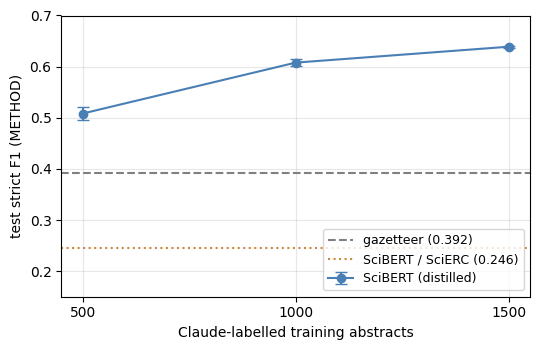

In [6]:
import matplotlib.pyplot as plt

sizes  = [500, 1000, 1500]
means  = [agg(f'results_{n}.json')[0] for n in sizes]
stds   = [agg(f'results_{n}.json')[1] for n in sizes]
scierc = agg('results_scierc.json')[0]

plt.figure(figsize=(5.5, 3.6))
plt.errorbar(sizes, means, yerr=stds, marker='o', capsize=4,
             color='#4a7fb5', label='SciBERT (distilled)')
plt.axhline(g['strict_f1'], ls='--', c='gray',
            label=f"gazetteer ({g['strict_f1']:.3f})")
plt.axhline(scierc, ls=':', c='#c98a3c',
            label=f'SciBERT / SciERC ({scierc:.3f})')

plt.xlabel('Claude-labelled training abstracts')
plt.ylabel('test strict F1 (METHOD)')
plt.xticks(sizes)
plt.ylim(0.15, 0.70)
plt.legend(fontsize=9, loc='lower right')
plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()
